<a href="https://colab.research.google.com/github/nikhitha2007/ML-SKILL/blob/main/08_Heart_Disease_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HEART DISEASE - DECISION TREE CLASSIFICATION

First five rows:
   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  

Dataset shape: (303, 14)

Column names: ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output']

Target distribution:
output
1    165
0    138
Name: count, dtype: int64

MODEL EVALUATION
Accuracy: 0.7705

Classification Report:
              precision    recall  f

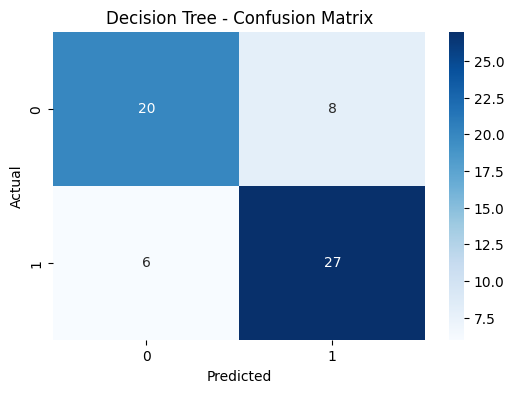

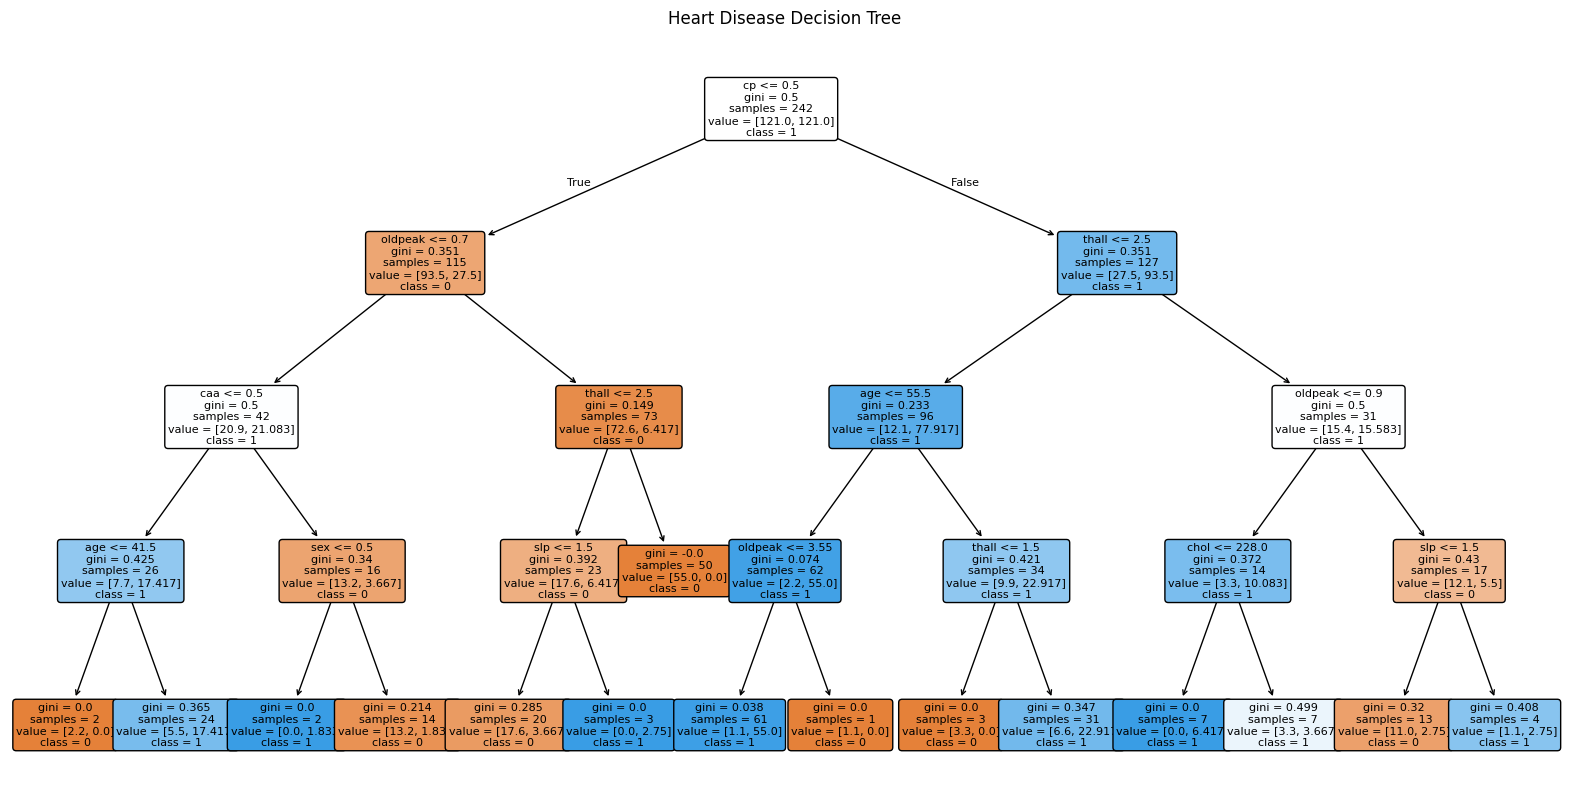


Top 10 Important Features:
cp         0.441712
oldpeak    0.180948
thall      0.147566
age        0.063905
slp        0.060449
caa        0.056113
sex        0.030915
chol       0.018391
trtbps     0.000000
exng       0.000000
dtype: float64


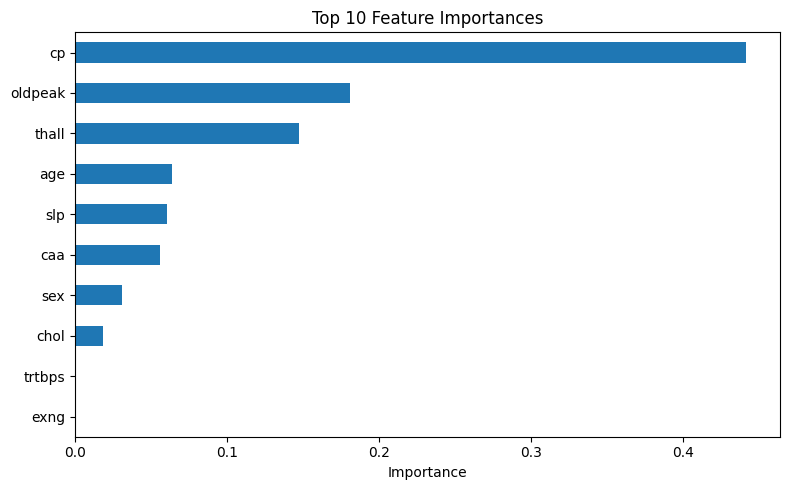


Predictions saved successfully!
PROGRAM 8 COMPLETED SUCCESSFULLY!


In [1]:

# PROGRAM 8: HEART DISEASE - DECISION TREE CLASSIFICATION

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

# 1. Load the dataset from a working source
url = "https://raw.githubusercontent.com/ramtinmt/heart-disease-classification/main/heart.csv"

df = pd.read_csv(url)

print("HEART DISEASE - DECISION TREE CLASSIFICATION")
print("=" * 55)

# 2. Display dataset information
print("\nFirst five rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

# 3. Prepare the target column
if "target" in df.columns:
    target_col = "target"
elif "output" in df.columns:
    target_col = "output"
elif "disease" in df.columns:
    target_col = "disease"
else:
    raise ValueError("Target column not found. Check the column names above.")

df = df.dropna(subset=[target_col]).copy()

X = df.drop(columns=[target_col])
y = df[target_col]

# Convert any categorical features to numeric columns
X = pd.get_dummies(X, drop_first=False)
X = X.replace([float("inf"), float("-inf")], float("nan"))

print("\nTarget distribution:")
print(y.value_counts())

# 4. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 5. Handle missing feature values
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

# 6. Create and train the Decision Tree
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# 7. Make predictions
y_pred = model.predict(X_test)

# 8. Evaluate the model
print("\nMODEL EVALUATION")
print("=" * 55)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# 9. Display confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 10. Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Heart Disease Decision Tree")
plt.show()

# 11. Display feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

importance.head(10).sort_values().plot(
    kind="barh", figsize=(8, 5)
)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 12. Save predictions
results = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred
})
results.to_csv("heart_disease_decision_tree_predictions.csv", index=False)

print("\nPredictions saved successfully!")
print("PROGRAM 8 COMPLETED SUCCESSFULLY!")